In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
input_path = "../data/feature_engineered/vegetable_prices_fe.csv"
df = pd.read_csv(input_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (4638, 67)
Columns: ['vegetable', 'price', 'Badulla_actual_class', 'Hambantota_actual_class', 'Jaffna_actual_class', 'Kurunegala_actual_class', 'Matale_actual_class', 'Nuwara_Eliya_actual_class', 'Ratnapura_actual_class', 'Badulla_prob_drought', 'Hambantota_prob_drought', 'Jaffna_prob_drought', 'Kurunegala_prob_drought', 'Matale_prob_drought', 'Nuwara_Eliya_prob_drought', 'Ratnapura_prob_drought', 'Badulla_prob_flood_risk', 'Hambantota_prob_flood_risk', 'Jaffna_prob_flood_risk', 'Kurunegala_prob_flood_risk', 'Matale_prob_flood_risk', 'Nuwara_Eliya_prob_flood_risk', 'Ratnapura_prob_flood_risk', 'Badulla_prob_normal', 'Hambantota_prob_normal', 'Jaffna_prob_normal', 'Kurunegala_prob_normal', 'Matale_prob_normal', 'Nuwara_Eliya_prob_normal', 'Ratnapura_prob_normal', 'USD_LKR_avg', 'RateChange_avg', 'week_num', 'price_lag1', 'price_lag2', 'price_roll_mean_4', 'price_roll_std_4', 'avg_prob_drought', 'max_prob_drought', 'min_prob_drought', 'std_prob_drought', 'avg_prob_flood_ri

,vegetable,price,Badulla_actual_class,Hambantota_actual_class,Jaffna_actual_class,Kurunegala_actual_class,Matale_actual_class,Nuwara_Eliya_actual_class,Ratnapura_actual_class,Badulla_prob_drought,...,USD_LKR_avg_sq,RateChange_avg_%_sq,week_num_sq,week_sin,week_cos,veg_2,veg_3,veg_4,veg_5,veg_6
0,1,58.6,0,-1,-1,0,-1,-1,-1,0.000156,...,13075.9225,0.0081,9,0.354605,0.935016,0,0,0,0,0
1,2,67.0,0,-1,-1,0,-1,-1,-1,0.000156,...,13075.9225,0.0081,9,0.354605,0.935016,1,0,0,0,0
2,3,47.5,0,-1,-1,0,-1,-1,-1,0.000156,...,13075.9225,0.0081,9,0.354605,0.935016,0,1,0,0,0
3,4,105.0,0,-1,-1,0,-1,-1,-1,0.000156,...,13075.9225,0.0081,9,0.354605,0.935016,0,0,1,0,0
4,5,22.5,0,-1,-1,0,-1,-1,-1,0.000156,...,13075.9225,0.0081,9,0.354605,0.935016,0,0,0,1,0


In [3]:
# Look at the first 100 rows to see week pattern
print("First 100 rows - week_num pattern:")
print(df['week_num'].head(100).tolist())

# Count how many times week_num resets from 52 to 1
resets = (df['week_num'].diff() < 0).sum()
print(f"\nNumber of times week_num resets (52→1): {resets}")
print(f"This suggests approximately {resets + 1} years of data.")

First 100 rows - week_num pattern:
[3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 22, 22, 22, 22]

Number of times week_num resets (52→1): 16
This suggests approximately 17 years of data.


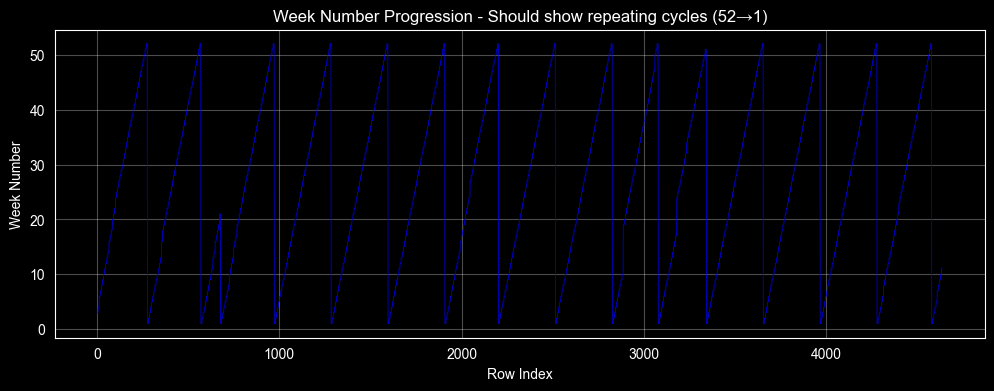

In [4]:
# Plot week_num over row index to verify chronology
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['week_num'], 'b-', linewidth=0.5)
plt.xlabel('Row Index')
plt.ylabel('Week Number')
plt.title('Week Number Progression - Should show repeating cycles (52→1)')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Find indices where week_num resets (52 → 1) - these mark year boundaries
reset_indices = df[df['week_num'].diff() < 0].index.tolist()

# Add start (0) and end (len(df)) for complete boundaries
year_boundaries = [0] + reset_indices + [len(df)]
print(f"Year boundaries at row indices: {year_boundaries}")
print(f"Total number of complete years: {len(year_boundaries) - 1}")

# Display each year's row range
for i in range(len(year_boundaries) - 1):
    start = year_boundaries[i]
    end = year_boundaries[i+1] - 1
    print(f"Year {i+1}: rows {start} to {end} ({end-start+1} rows)")

Year boundaries at row indices: [0, 276, 570, 678, 972, 1284, 1596, 1908, 2202, 2514, 2826, 3078, 3342, 3654, 3966, 4278, 4578, 4638]
Total number of complete years: 17
Year 1: rows 0 to 275 (276 rows)
Year 2: rows 276 to 569 (294 rows)
Year 3: rows 570 to 677 (108 rows)
Year 4: rows 678 to 971 (294 rows)
Year 5: rows 972 to 1283 (312 rows)
Year 6: rows 1284 to 1595 (312 rows)
Year 7: rows 1596 to 1907 (312 rows)
Year 8: rows 1908 to 2201 (294 rows)
Year 9: rows 2202 to 2513 (312 rows)
Year 10: rows 2514 to 2825 (312 rows)
Year 11: rows 2826 to 3077 (252 rows)
Year 12: rows 3078 to 3341 (264 rows)
Year 13: rows 3342 to 3653 (312 rows)
Year 14: rows 3654 to 3965 (312 rows)
Year 15: rows 3966 to 4277 (312 rows)
Year 16: rows 4278 to 4577 (300 rows)
Year 17: rows 4578 to 4637 (60 rows)


In [6]:
# Calculate number of years for each set
total_years = len(year_boundaries) - 1
train_years = int(0.7 * total_years)
val_years = int(0.15 * total_years)
test_years = total_years - train_years - val_years

print(f"Total years: {total_years}")
print(f"Training: {train_years} years ({train_years/total_years:.1%})")
print(f"Validation: {val_years} years ({val_years/total_years:.1%})")
print(f"Test: {test_years} years ({test_years/total_years:.1%})")
print("-" * 50)

# Get row indices for each split
train_end_idx = year_boundaries[train_years]
val_end_idx = year_boundaries[train_years + val_years]

# Split the data
train_df = df.iloc[:train_end_idx].copy()
val_df = df.iloc[train_end_idx:val_end_idx].copy()
test_df = df.iloc[val_end_idx:].copy()

print(f"Training: rows 0 to {train_end_idx-1} (Years 1-{train_years})")
print(f"Validation: rows {train_end_idx} to {val_end_idx-1} (Years {train_years+1}-{train_years+val_years})")
print(f"Test: rows {val_end_idx} to {len(df)-1} (Years {train_years+val_years+1}-{total_years})")
print(f"\nTotal rows: {len(train_df) + len(val_df) + len(test_df)} = {len(df)}")

Total years: 17
Training: 11 years (64.7%)
Validation: 2 years (11.8%)
Test: 4 years (23.5%)
--------------------------------------------------
Training: rows 0 to 3077 (Years 1-11)
Validation: rows 3078 to 3653 (Years 12-13)
Test: rows 3654 to 4637 (Years 14-17)

Total rows: 4638 = 4638


In [7]:
print("=" * 60)
print("VERIFICATION OF SPLITS")
print("=" * 60)

# Training set info
print(f"\n📊 TRAINING SET:")
print(f"   Rows: 0 to {train_end_idx-1}")
print(f"   Year range: Years 1 to {train_years}")
print(f"   Week numbers present: {sorted(train_df['week_num'].unique())}")
print(f"   Total rows: {len(train_df)}")

# Validation set info
print(f"\n📊 VALIDATION SET:")
print(f"   Rows: {train_end_idx} to {val_end_idx-1}")
print(f"   Year range: Years {train_years+1} to {train_years+val_years}")
print(f"   Week numbers present: {sorted(val_df['week_num'].unique())}")
print(f"   Total rows: {len(val_df)}")

# Test set info
print(f"\n📊 TEST SET:")
print(f"   Rows: {val_end_idx} to {len(df)-1}")
print(f"   Year range: Years {train_years+val_years+1} to {total_years}")
print(f"   Week numbers present: {sorted(test_df['week_num'].unique())}")
print(f"   Total rows: {len(test_df)}")

# Verify clean breaks
print("\n" + "=" * 60)
print("BOUNDARY VERIFICATION:")
print(f"Last training row index: {train_end_idx-1}")
print(f"First validation row index: {train_end_idx}")
print(f"Last validation row index: {val_end_idx-1}")
print(f"First test row index: {val_end_idx}")

if train_end_idx == year_boundaries[train_years]:
    print("✅ Clean break between training and validation (end of year)")
if val_end_idx == year_boundaries[train_years + val_years]:
    print("✅ Clean break between validation and test (end of year)")

VERIFICATION OF SPLITS

📊 TRAINING SET:
   Rows: 0 to 3077
   Year range: Years 1 to 11
   Week numbers present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
   Total rows: 3078

📊 VALIDATION SET:
   Rows: 3078 to 3653
   Year range: Years 12 to 13
   Week numbers present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
   Total rows: 576

📊 TEST SET:
   Rows: 3654 to 4637
   Year range: Years 14 to 17
   Week numbers present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
   Total rows: 984

BOUNDARY VERIFICATION:
Last training row i

In [8]:
# Create a DataFrame showing which set each year belongs to
years_allocation = []
for i in range(total_years):
    start_row = year_boundaries[i]
    end_row = year_boundaries[i+1] - 1
    year_num = i + 1

    if year_num <= train_years:
        set_name = "TRAIN"
    elif year_num <= train_years + val_years:
        set_name = "VALIDATION"
    else:
        set_name = "TEST"

    years_allocation.append({
        'Year': year_num,
        'Set': set_name,
        'Start Row': start_row,
        'End Row': end_row,
        'Row Count': end_row - start_row + 1
    })

allocation_df = pd.DataFrame(years_allocation)
print("YEAR ALLOCATION DETAILS:")
print(allocation_df.to_string(index=False))

print("\n" + "=" * 60)
print("SUMMARY BY SET:")
print(allocation_df.groupby('Set')['Row Count'].sum().to_string())

YEAR ALLOCATION DETAILS:
 Year        Set  Start Row  End Row  Row Count
    1      TRAIN          0      275        276
    2      TRAIN        276      569        294
    3      TRAIN        570      677        108
    4      TRAIN        678      971        294
    5      TRAIN        972     1283        312
    6      TRAIN       1284     1595        312
    7      TRAIN       1596     1907        312
    8      TRAIN       1908     2201        294
    9      TRAIN       2202     2513        312
   10      TRAIN       2514     2825        312
   11      TRAIN       2826     3077        252
   12 VALIDATION       3078     3341        264
   13 VALIDATION       3342     3653        312
   14       TEST       3654     3965        312
   15       TEST       3966     4277        312
   16       TEST       4278     4577        300
   17       TEST       4578     4637         60

SUMMARY BY SET:
Set
TEST           984
TRAIN         3078
VALIDATION     576


In [9]:
# This check is now less critical since we split by years,
# but we'll verify that each set contains all 52 weeks
print("CHECKING WEEK COVERAGE:")
print("-" * 40)

train_weeks = set(train_df['week_num'].unique())
val_weeks = set(val_df['week_num'].unique())
test_weeks = set(test_df['week_num'].unique())

print(f"Training set weeks: {sorted(train_weeks)}")
print(f"Validation set weeks: {sorted(val_weeks)}")
print(f"Test set weeks: {sorted(test_weeks)}")

print(f"\nAll sets contain all 52 weeks: {train_weeks == val_weeks == test_weeks == set(range(1, 53))}")

CHECKING WEEK COVERAGE:
----------------------------------------
Training set weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
Validation set weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
Test set weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

All sets contain all 52 weeks: True


In [10]:
output_dir = "../data/splits"
os.makedirs(output_dir, exist_ok=True)

# Save each split
train_df.to_csv(os.path.join(output_dir, "train.csv"), index=False)
val_df.to_csv(os.path.join(output_dir, "validation.csv"), index=False)
test_df.to_csv(os.path.join(output_dir, "test.csv"), index=False)

print(f"✅ SPLITS SAVED TO: {output_dir}")
print("-" * 50)
print(f"📁 train.csv: {len(train_df):,} rows ({train_years} years)")
print(f"📁 validation.csv: {len(val_df):,} rows ({val_years} years)")
print(f"📁 test.csv: {len(test_df):,} rows ({test_years} years)")
print("-" * 50)
print(f"Total rows saved: {len(train_df) + len(val_df) + len(test_df):,}")

# Also save split information for reference
split_info = pd.DataFrame([{
    'split': 'train',
    'years': f'1-{train_years}',
    'rows': len(train_df),
    'row_indices': f'0-{train_end_idx-1}'
}, {
    'split': 'validation',
    'years': f'{train_years+1}-{train_years+val_years}',
    'rows': len(val_df),
    'row_indices': f'{train_end_idx}-{val_end_idx-1}'
}, {
    'split': 'test',
    'years': f'{train_years+val_years+1}-{total_years}',
    'rows': len(test_df),
    'row_indices': f'{val_end_idx}-{len(df)-1}'
}])

split_info.to_csv(os.path.join(output_dir, "split_info.csv"), index=False)
print("\n📁 split_info.csv saved with split details")

✅ SPLITS SAVED TO: ../data/splits
--------------------------------------------------
📁 train.csv: 3,078 rows (11 years)
📁 validation.csv: 576 rows (2 years)
📁 test.csv: 984 rows (4 years)
--------------------------------------------------
Total rows saved: 4,638

📁 split_info.csv saved with split details


In [11]:
print("TRAINING SET - First 5 rows:")
print(train_df[['week_num', 'vegetable', 'price']].head())
print("\n" + "=" * 60)

print("VALIDATION SET - First 5 rows:")
print(val_df[['week_num', 'vegetable', 'price']].head())
print("\n" + "=" * 60)

print("TEST SET - First 5 rows:")
print(test_df[['week_num', 'vegetable', 'price']].head())

TRAINING SET - First 5 rows:
   week_num  vegetable  price
0         3          1   58.6
1         3          2   67.0
2         3          3   47.5
3         3          4  105.0
4         3          5   22.5

VALIDATION SET - First 5 rows:
      week_num  vegetable  price
3078         1          1  192.0
3079         1          2   58.0
3080         1          3   11.4
3081         1          4  102.0
3082         1          5   88.0

TEST SET - First 5 rows:
      week_num  vegetable  price
3654         1          1  280.0
3655         1          2  370.0
3656         1          3   77.0
3657         1          4  194.0
3658         1          5  124.0
